<a href="https://colab.research.google.com/github/aryixa/closetai/blob/main/closet_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Fashion Stylist
Full Pipeline: CV + Similarity + RAG + UI

In [19]:
!pip install torch torchvision matplotlib opencv-python faiss-cpu sentence-transformers transformers gradio

In [20]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', device)

Using: cuda


In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False)
print(len(dataset))

60000


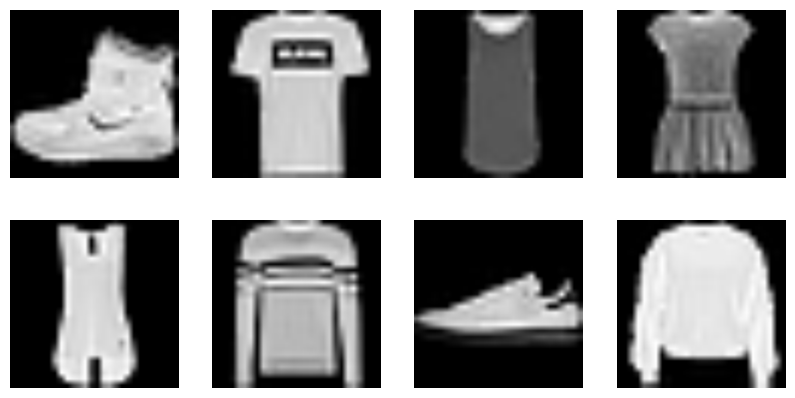

In [22]:
import matplotlib.pyplot as plt
imgs, lbls = next(iter(loader))
plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(imgs[i].permute(1,2,0))
    plt.axis('off')
plt.show()

In [23]:
import torchvision.models as models
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [24]:
embeddings = []
labels_list = []

with torch.no_grad():
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        out = model(imgs)
        out = out.view(out.size(0), -1)
        embeddings.append(out.cpu())
        labels_list.append(lbls)

embeddings = torch.cat(embeddings, dim=0)
labels_list = torch.cat(labels_list, dim=0)

print(embeddings.shape)

torch.Size([60000, 512])


In [25]:
import torch.nn.functional as F
vecs = F.normalize(embeddings, dim=1)
query = vecs[0].unsqueeze(0)
sim = torch.mm(query, vecs.T)
_, indices = torch.topk(sim, k=5)
indices

tensor([[    0, 21314, 12900, 38612, 38246]])

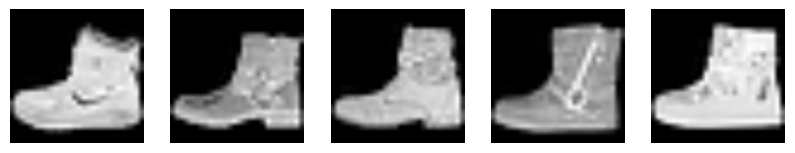

In [26]:
plt.figure(figsize=(10,3))
for i, idx in enumerate(indices[0]):
    img, _ = dataset[idx]
    plt.subplot(1,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.axis('off')
plt.show()

In [27]:
import numpy as np
def get_color(img):
    img = img.permute(1,2,0).numpy()
    img = (img * 255).astype(np.uint8)
    avg = img.mean(axis=(0,1))
    return avg.astype(int)

img, _ = dataset[0]
print('Color:', get_color(img))

Color: [97 97 97]


In [28]:
fashion_docs = [
    "Wear light colors like white or pastel in summer.",
    "Dark colors like black and navy are suitable for formal events.",
    "Avoid mixing too many patterns in one outfit.",
    "Neutral colors like beige, white, and gray match easily.",
    "Cotton fabrics are best for hot weather.",
    "Wool fabrics are good for winter.",
    "For parties, choose bold colors and stylish outfits.",
    "For office wear, choose simple and clean designs.",
    "Bright colors are good for casual outings.",
    "Layering works well in cold weather.",
    "Comfort is important for daily wear.",
    "Choose loose clothes in summer for better airflow."
]

In [29]:
from sentence_transformers import SentenceTransformer
text_model = SentenceTransformer('all-MiniLM-L6-v2')
doc_embeddings = text_model.encode(fashion_docs, normalize_embeddings=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
import faiss
dim = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(doc_embeddings.astype('float32'))

def retrieve(query):
    q = text_model.encode([query], normalize_embeddings=True)
    D, I = index.search(q.astype('float32'), k=4)
    return [fashion_docs[i] for i in I[0]]

print(retrieve('summer outfit'))

['Choose loose clothes in summer for better airflow.', 'Wear light colors like white or pastel in summer.', 'For parties, choose bold colors and stylish outfits.', 'Avoid mixing too many patterns in one outfit.']


In [31]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
llm = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base').to(device)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [40]:
def generate(query):
    rules = retrieve(query)
    context = '\n'.join(rules)

    prompt = f"""
Answer the question using only the rules below.

Question: {query}

Rules:
{context}

Answer:

Outfit:
Reason:
Tips:
"""

    inputs = tokenizer(prompt, return_tensors='pt').to(device)

    outputs = llm.generate(
        **inputs,
        max_length=120,
        min_length=40,
        num_beams=4,
        do_sample=False,
        repetition_penalty=1.1,
        no_repeat_ngram_size=2,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


# test
print(generate("What should I wear in summer?"))

Choose light colors like white or pastel in summer for better airflow. For parties, choose bold colours and stylish outfits to make them stand out from the rest of a party group by choosing loose clothes
